In [44]:
import sys
import os

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
from dataset.mnist import load_mnist
from multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [45]:
sys.path.append('./fashion-mnist/utils/')

In [46]:
import mnist_reader
x_train, t_train = mnist_reader.load_mnist('./fashion-mnist/data/fashion', kind='train')
x_test, t_test = mnist_reader.load_mnist('./fashion-mnist/data/fashion', kind='t10k')

# ## data normalization
# x_train = x_train / 255.0
# x_test = x_test / 255.0 

In [47]:
print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(60000, 784)
255
(60000,)


In [48]:
network_dict = {
                'step': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='step', weight_init_std=0.01),
                'sigmoid': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='sigmoid', weight_init_std=0.01),
                'tanh': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='tanh', weight_init_std=0.01),
                'relu': MultiLayerNetExtend(input_size=784, hidden_size_list=[50], output_size=10, activation='relu', weight_init_std=0.01),
                'leaky': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std=0.01),
                }

In [49]:
network_dict['relu'].params.keys()

dict_keys(['W1', 'b1', 'W2', 'b2'])

In [50]:
# 하이퍼 파라메터
iters_num = 10_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [51]:
output_dict = {}
for key, network in network_dict.items():

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
        
    print('='*10)
    print('\n\n')


=== step network training start ===
--- step result report ---
train acc, test acc | 0.18111666666666668, 0.1817
--- step result report ---
train acc, test acc | 0.7427666666666667, 0.7339
--- step result report ---
train acc, test acc | 0.7525833333333334, 0.7425
--- step result report ---
train acc, test acc | 0.7580666666666667, 0.7468
--- step result report ---
train acc, test acc | 0.7593833333333333, 0.7498
--- step result report ---
train acc, test acc | 0.7576, 0.7482
--- step result report ---
train acc, test acc | 0.76025, 0.7513
--- step result report ---
train acc, test acc | 0.7629333333333334, 0.7525
--- step result report ---
train acc, test acc | 0.7617166666666667, 0.7529
--- step result report ---
train acc, test acc | 0.7627333333333334, 0.7508
--- step result report ---
train acc, test acc | 0.7624833333333333, 0.7548
--- step result report ---
train acc, test acc | 0.7659333333333334, 0.7544
--- step result report ---
train acc, test acc | 0.7665833333333333, 0.756

/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/../../official_github/common/functions.py:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


--- sigmoid result report ---
train acc, test acc | 0.66555, 0.6624
--- sigmoid result report ---
train acc, test acc | 0.6669166666666667, 0.6622
--- sigmoid result report ---
train acc, test acc | 0.6856, 0.6799
--- sigmoid result report ---
train acc, test acc | 0.6200666666666667, 0.6135
--- sigmoid result report ---
train acc, test acc | 0.6069, 0.6035
--- sigmoid result report ---
train acc, test acc | 0.57575, 0.5641
--- sigmoid result report ---
train acc, test acc | 0.639, 0.629
--- sigmoid result report ---
train acc, test acc | 0.6512333333333333, 0.6467
--- sigmoid result report ---
train acc, test acc | 0.63355, 0.6324
--- sigmoid result report ---
train acc, test acc | 0.6596833333333333, 0.6582
--- sigmoid result report ---
train acc, test acc | 0.68315, 0.6742
--- sigmoid result report ---
train acc, test acc | 0.6656, 0.6584
--- sigmoid result report ---
train acc, test acc | 0.6434666666666666, 0.6322
--- sigmoid result report ---
train acc, test acc | 0.65025, 0.6431

/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/../../official_github/common/functions.py:56: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size


--- relu result report ---
train acc, test acc | 0.19765, 0.1975
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.0999
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.0999
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1



/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/../../official_github/common/functions.py:34: RuntimeWarning: overflow encountered in subtract
  x = x - np.max(x, axis=0)
/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/../../official_github/common/functions.py:34: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1





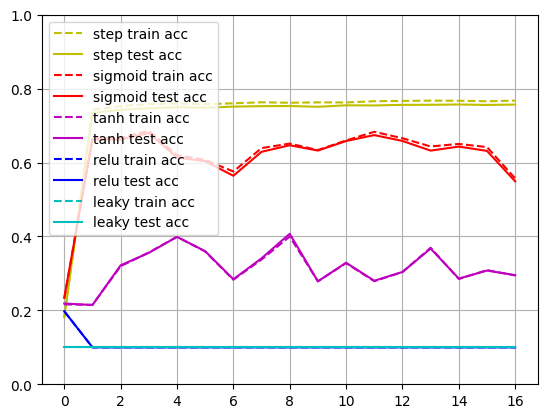

In [52]:
for k, v in output_dict.items():
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
plt.ylim([0.0, 1.0])
plt.legend()
plt.grid()